In [1]:
import pandas as pd
import networkx as nx

# Load LOP subnetwork
lop_nodes = pd.read_csv("../data/preprocessed/lop_nodes.csv")
lop_edges = pd.read_csv("../data/preprocessed/lop_edges.csv")

print("Nodes:", lop_nodes.shape)
print("Edges:", lop_edges.shape)

lop_nodes.head(), lop_edges.head()


(1913, 20552)

In [2]:
# Build the directed data

G = nx.from_pandas_edgelist(
    lop_edges,
    source="pre",
    target="post",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print("Number of nodes in G:", G.number_of_nodes())
print("Number of edges in G:", G.number_of_edges())


Number of nodes in G: 1913
Number of edges in G: 20552


### Network size & density

In [3]:
n = G.number_of_nodes()
m = G.number_of_edges()

density = nx.density(G)

print(f"Nodes (n): {n}")
print(f"Edges (m): {m}")
print(f"Density: {density:.6f}")


Nodes (n): 1913
Edges (m): 20552
Density: 0.005619


## In-degree vs Out-degree

In [4]:
in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print("Average in-degree:", sum(in_degrees) / len(in_degrees))
print("Average out-degree:", sum(out_degrees) / len(out_degrees))


Average in-degree: 10.743335075797177
Average out-degree: 10.743335075797177


In any directed graph:

sum(in-degrees) = sum(out-degrees) = number of edges

So averages must match

### Edge weight statistics

In [5]:
weights = lop_edges["weight"]

weights.describe()


count    20552.000000
mean        16.110987
std         43.974482
min          5.000000
25%          6.000000
50%          9.000000
75%         17.000000
max       1737.000000
Name: weight, dtype: float64


- Most synapses are small to moderate
- A few connections are extremely strong
- Heavy-tailed distribution → classic biological signature
  
#### Strong edges may define:

- dominant pathways

- feed-forward circuits

#### Weak edges may represent:

- background conn

### Degree Distributions

In [6]:
import numpy as np

# Compute degrees
in_degrees = np.array([d for _, d in G.in_degree()])
out_degrees = np.array([d for _, d in G.out_degree()])

print("In-degree stats:")
print(pd.Series(in_degrees).describe())

print("\nOut-degree stats:")
print(pd.Series(out_degrees).describe())


In-degree stats:
count    1913.000000
mean       10.743335
std        19.873462
min         0.000000
25%         4.000000
50%         8.000000
75%        12.000000
max       368.000000
dtype: float64

Out-degree stats:
count    1913.000000
mean       10.743335
std        27.634768
min         0.000000
25%         3.000000
50%         6.000000
75%        11.000000
max       518.000000
dtype: float64


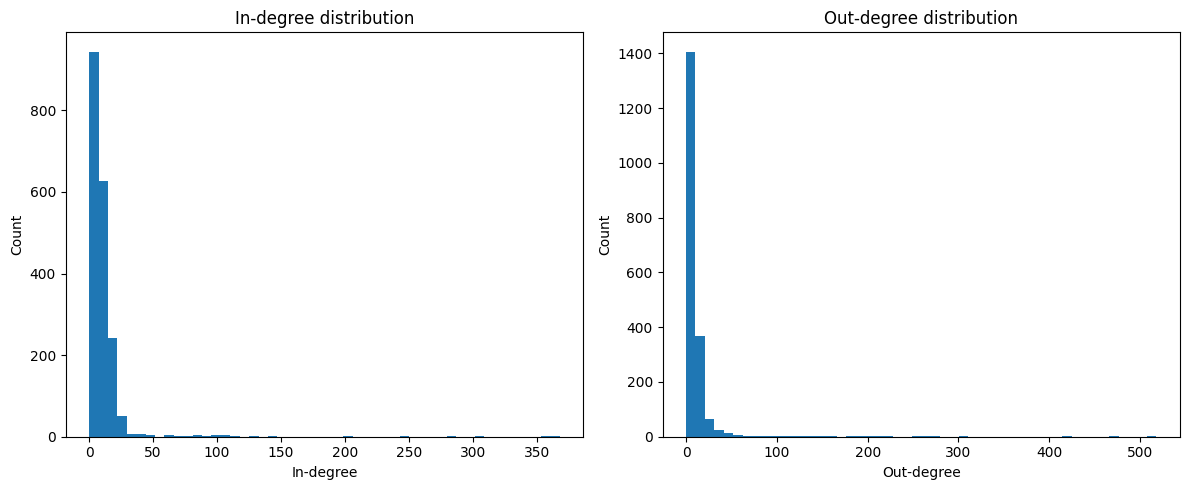

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(in_degrees, bins=50)
plt.title("In-degree distribution")
plt.xlabel("In-degree")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(out_degrees, bins=50)
plt.title("Out-degree distribution")
plt.xlabel("Out-degree")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


### 1. Strong right-skewed (heavy-tailed) distributions

- Both the in-degree and out-degree histograms are highly right-skewed:

- The vast majority of neurons have very low degree

- A small number of neurons have extremely high degree (long tail up to hundreds)

- This indicates that the LOP network is hub-dominated, not homogeneous.
### 2. Presence of rare but very strong hubs

- In-degree reaches well above 300

- Out-degree reaches even higher (above 500)

This suggests:

- Some neurons act as major information receivers

- Some neurons act as major information broadcasters

- These hubs likely play a central role in visual information flow

### 3. Similar global shape for in- and out-degree

- The overall shapes of the two distributions are similar, which implies:

- The network is globally balanced in terms of total incoming vs outgoing connections

- However, individual neurons may still be specialized (sender vs receiver)

This balance is consistent with:

Directed but well-organized feedforward and feedback pathways

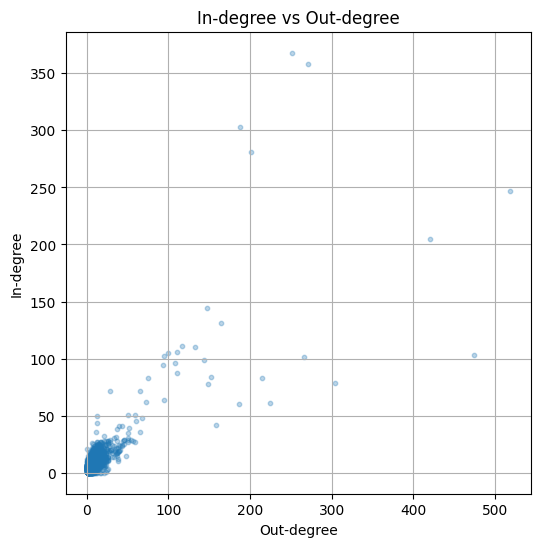

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(out_degrees, in_degrees, alpha=0.3, s=10)

plt.xlabel("Out-degree")
plt.ylabel("In-degree")
plt.title("In-degree vs Out-degree")

plt.grid(True)
plt.show()


The LOP network is sparse but structured

It resembles a scale-free or truncated scale-free network

Random graph models would not reproduce this degree pattern

### Visualization 1 — Strong-edge backbone network

Only show strong synaptic connections.

This reveals the core information pathways.

In [9]:
# Define threshold (top 10% strongest edges)
threshold = lop_edges["weight"].quantile(0.90)
threshold


np.float64(29.0)

In [10]:
# Build the backbone graph

strong_edges = lop_edges[lop_edges["weight"] >= threshold]

G_backbone = nx.from_pandas_edgelist(
    strong_edges,
    source="pre",
    target="post",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print("Backbone nodes:", G_backbone.number_of_nodes())
print("Backbone edges:", G_backbone.number_of_edges())


Backbone nodes: 1144
Backbone edges: 2123


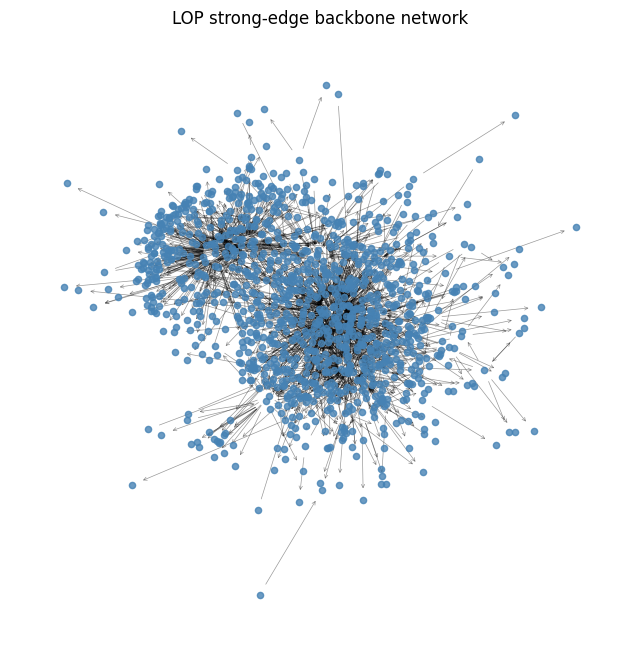

In [17]:
plt.figure(figsize=(8, 8))

pos = nx.spring_layout(G_backbone, k=0.3, seed=42)

nx.draw_networkx_nodes(
    G_backbone,
    pos,
    node_size=20,
    node_color="steelblue",
    alpha=0.8
)

nx.draw_networkx_edges(
    G_backbone,
    pos,
    arrowstyle="->",
    arrowsize=6,
    width=0.5,
    alpha=0.4
)

plt.title("LOP strong-edge backbone network")
plt.axis("off")
plt.show()


This plot shows only the strongest synaptic connections in the LOP network.

- Weak edges (low synapse count) are filtered out, leaving a backbone of dominant information flow.

- Nodes = neurons

- Arrows = strong directed synaptic connections

The network collapses into a dense core plus peripheral branches.

### This suggests:

- A central processing core where many strong interactions happen

- Peripheral neurons that mainly send to or receive from the core

- Directionality is visible: many arrows point outward from core regions → strong evidence of feed-forward structure

### Visualization 2 — Ego networks of hubs
Instead of drawing everything:

Pick important neurons

Visualize their local neighborhoods

In [13]:
#Identify Hubs
# Top 5 out-degree nodes
top_out_nodes = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:5]
top_out_nodes


[(720575940634612194, 518),
 (720575940620008758, 474),
 (720575940619991862, 421),
 (720575940629382150, 304),
 (720575940632504874, 271)]

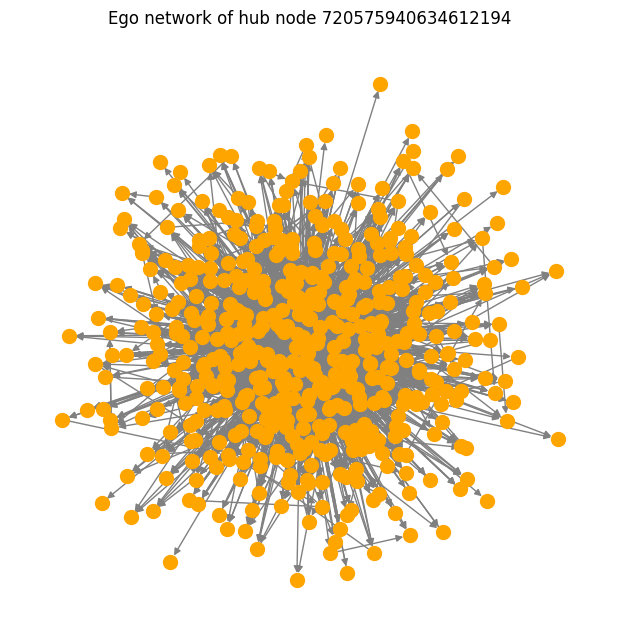

In [14]:
#Draw ego network for one hub
hub = top_out_nodes[0][0]

ego = nx.ego_graph(G, hub, radius=1, center=True, undirected=False)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(ego, seed=42)

nx.draw(
    ego,
    pos,
    with_labels=False,
    node_size=100,
    node_color="orange",
    edge_color="gray",
    arrowsize=10
)

plt.title(f"Ego network of hub node {hub}")
plt.axis("off")
plt.show()


The ego network shows:
- The hub
- All neurons directly connected to it (incoming and outgoing)
- Edges among them

The hub connects to a very large number of neurons
- Most connections are outgoing, meaning:
- This neuron is a strong sender
- It likely acts as a broadcast / integration node
- The ego network is dense and asymmetric → not just a local relay

In [15]:
# Sample ~150 nodes for visualization
sample_nodes = list(np.random.choice(G.nodes(), size=150, replace=False))
G_sample = G.subgraph(sample_nodes)


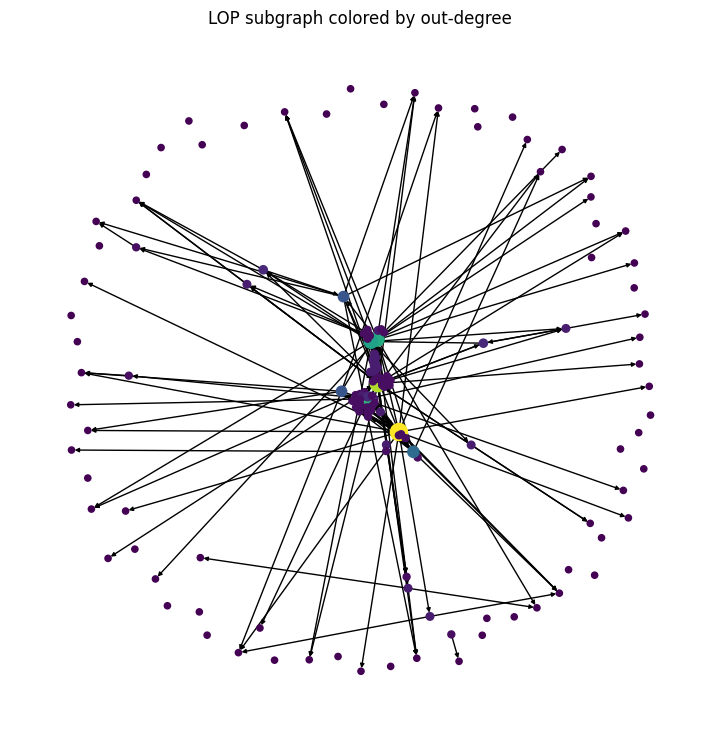

In [16]:
out_deg = dict(G_sample.out_degree())
node_sizes = [out_deg[n] * 5 + 20 for n in G_sample.nodes()]
node_colors = list(out_deg.values())

plt.figure(figsize=(7, 7))
pos = nx.spring_layout(G_sample, seed=42)

nx.draw(
    G_sample,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="viridis",
    with_labels=False,
    arrowsize=6
)

plt.title("LOP subgraph colored by out-degree")
plt.axis("off")
plt.show()


Each node is colored by out-degree (how many neurons it sends to)

Brighter / different colors = higher out-degree

Layout emphasizes directionality and centrality

- A small number of neurons dominate outgoing connections
- Many neurons sit at the periphery with very low out-degree
- Clear core–periphery structure
- Core: high out-degree (likely signal distributors)
- Periphery: mostly receivers or weak senders

## Conclusion 

### LOP is:
- Directed
- Sparse but structured
- Dominated by a small number of hubs

### Information flow is:

- Strongly asymmetric
- Organized around a dense core
- Simple undirected community detection would miss this structure